In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("gender_classification_v7.csv")

df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [4]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["gender"] = label_encoder.fit_transform(df["gender"])
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


Text(0.5, 1.0, 'Correlation Matrix')

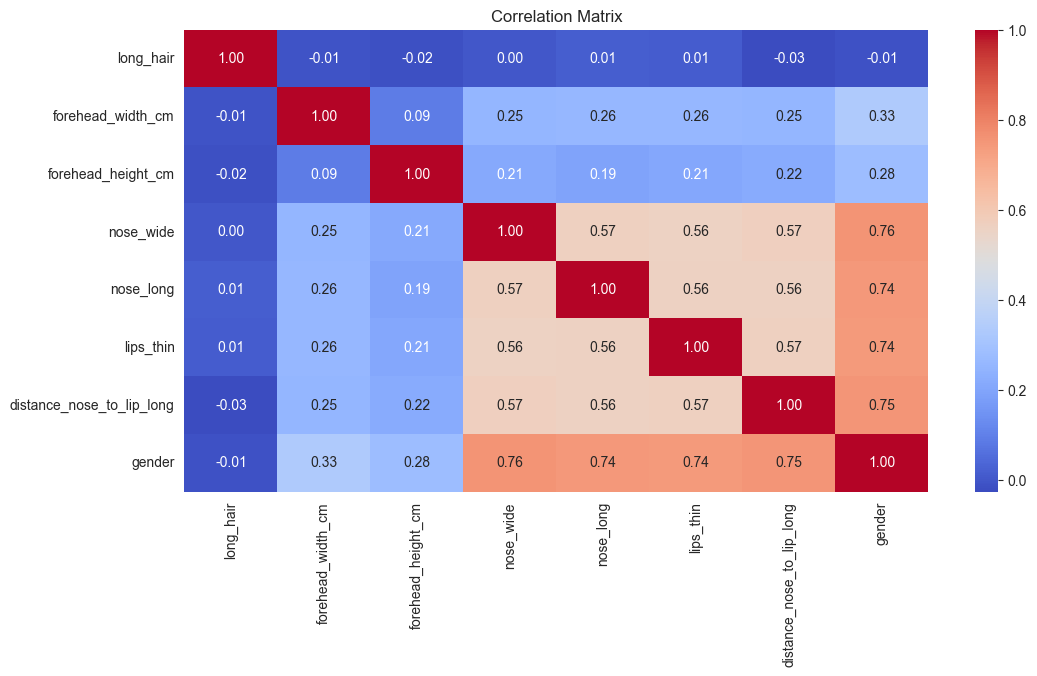

In [6]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('gender', axis=1)
y = df['gender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
from keras.src.optimizers import SGD
from keras.src.callbacks import EarlyStopping
from keras.src.layers import InputLayer, Dense
from keras import Sequential


def train_model(neurons, activation, learning_rate=0.1, epochs=500, batch_size=2):
    model = Sequential()

    model.add(InputLayer(shape=(X_train.shape[1],)))

    for neuron_num in neurons:
        model.add(Dense(neuron_num, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=SGD(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stopping]
    )

    return model, history

In [9]:
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_model(model, history, model_name):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{model_name} - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

    y_pred = (model.predict(X_test) > 0.5).astype("int32")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()



--- MODEL 1: Simple Network with ReLU Activation ---
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4982 - loss: 2.0307 - val_accuracy: 0.4855 - val_loss: 0.6957
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5237 - loss: 0.6893 - val_accuracy: 0.5015 - val_loss: 0.6802
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5623 - loss: 0.6743 - val_accuracy: 0.5275 - val_loss: 0.6673
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6038 - loss: 0.6607 - val_accuracy: 0.6054 - val_loss: 0.6514
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6917 - loss: 0.6412 - val_accuracy: 0.7552 - val_loss: 0.6322
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7700 - loss: 0.6229 - val_accuracy: 0.7772 - val_loss: 0.6125
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7299 - loss: 0.6171 - val_accuracy: 0.5005 - val_loss: 0.7462
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0

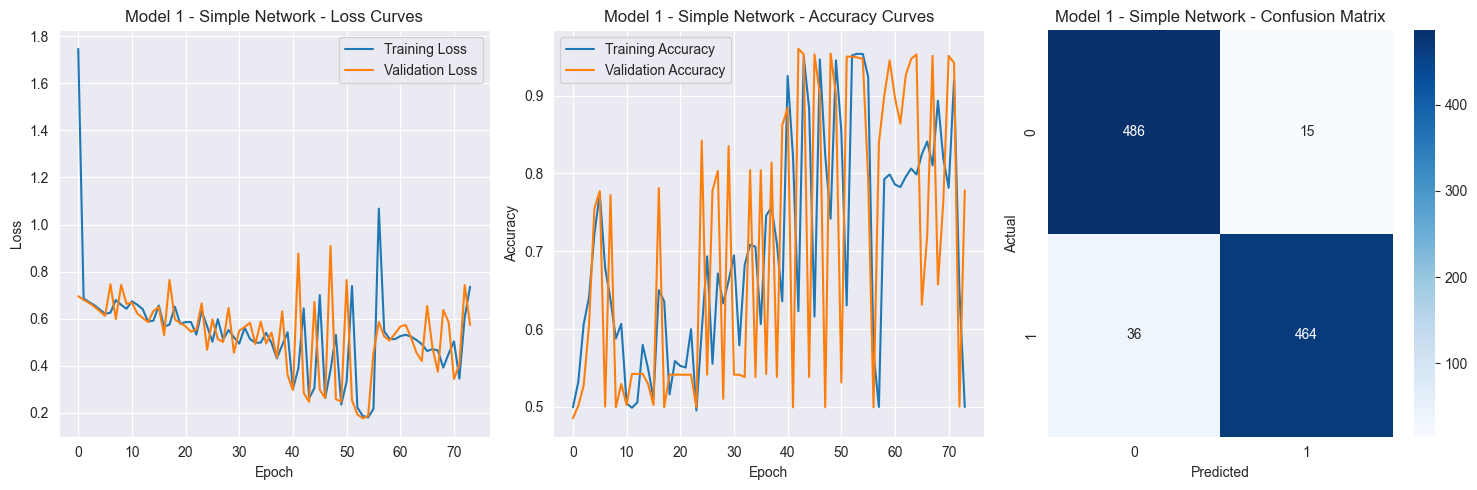

In [18]:
print("\n\n--- MODEL 1: Simple Network with ReLU Activation ---")
model1, history1 = train_model(
    neurons=[5],
    epochs=100,
    batch_size=1000,
    learning_rate=0.1,
    activation='relu'
)
evaluate_model(model1, history1, "Model 1 - Simple Network")

In [ ]:
model_names = [
    "Model 1 - Simple Network",
]

models = [model1]
histories = [history1]

In [ ]:
plt.figure(figsize=(12, 8))
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=model_names[i])

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()